<a href="https://colab.research.google.com/github/JeremyComellas/OpenSourceTools/blob/Thermal_Images_Classifier/Training_room_TH_img_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLASIFICADOR DE IMAGENES

## ANOTACIONES

In [18]:
import os
import csv

# Directorio base donde están las carpetas de clases
BASE_DIR = "/content/drive/MyDrive/ATOM2.0/classifier/train_data"

# Archivo de salida
OUTPUT_FILE = "/content/drive/MyDrive/ATOM2.0/classifier/train_data/annotations.csv"

# Obtener las carpetas que representan las clases
classes = [folder for folder in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, folder))]
print(classes)

# Lista para almacenar las anotaciones
annotations = []

# Recorrer cada carpeta de clase
for class_name in classes:
    class_path = os.path.join(BASE_DIR, class_name)
    print(class_path)

    # Recorrer las imágenes dentro de la carpeta
    for img_name in os.listdir(class_path):
        if img_name.endswith((".JPG")):  # Filtrar solo imágenes
            img_path = os.path.join(class_path, img_name)
            annotations.append([img_path, class_name])


# Guardar en un archivo CSV
with open(OUTPUT_FILE, mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["image_path", "label"])  # Encabezados
    writer.writerows(annotations)

print(f"✅ Archivo '{OUTPUT_FILE}' generado con éxito con {len(annotations)} anotaciones.")


['Vacio', 'Eje', 'Extremo']
/content/drive/MyDrive/ATOM2.0/classifier/train_data/Vacio
/content/drive/MyDrive/ATOM2.0/classifier/train_data/Eje
/content/drive/MyDrive/ATOM2.0/classifier/train_data/Extremo
✅ Archivo '/content/drive/MyDrive/ATOM2.0/classifier/train_data/annotations.csv' generado con éxito con 102 anotaciones.


### Preparación Dataset

In [19]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import os

# Configuración
BATCH_SIZE = 16
IMAGE_SIZE = 224  # ViT usa imágenes de 224x224

# Transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Redimensionar imágenes
    transforms.ToTensor(),  # Convertir a tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalización
])

# Cargar dataset
dataset_path = BASE_DIR  # Cambia esto si es necesario
dataset = ImageFolder(root=dataset_path, transform=transform)

# Dividir en entrenamiento y validación
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Cargar en DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Mostrar clases detectadas
print(f"Clases detectadas: {dataset.classes}")

Clases detectadas: ['Eje', 'Extremo', 'Vacio']


### Modelo ViT Pre-entrenado **General**

In [ ]:
# from transformers import ViTForImageClassification

# # Cargar modelo ViT preentrenado
# num_classes = 4  # Número de clases en tu dataset
# model = ViTForImageClassification.from_pretrained(
#     "google/vit-base-patch16-224",
#     num_labels=num_classes,
#     ignore_mismatched_sizes=True  # Ignorar errores de tamaño en la capa de clasificación
# )

# # Mover el modelo a GPU si está disponible
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# print(f"Modelo cargado en {device}")

### Modelo Vit desde **CheckPoint Previo**

In [22]:
from transformers import ViTForImageClassification
import torch

# Ruta al checkpoint guardado
checkpoint_path = "/content/drive/MyDrive/ATOM2.0/models/vit_classifier.pth"  # Cambia esto a la ruta real de tu checkpoint

# Mover el modelo a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar modelo con la misma arquitectura
num_classes = 4  # Número de clases en tu dataset
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True  # Ignorar errores de tamaño en la capa de clasificación
)

# Cargar pesos desde el checkpoint
model.load_state_dict(torch.load(checkpoint_path, map_location=device), strict=False)



# Mover el modelo a GPU si está disponible
model.to(device)

print(f"Modelo cargado desde checkpoint en {device}")


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-22-f65bf1549f46>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. Th

Modelo cargado desde checkpoint en cuda


### Configurar función de pérdida + Optimizador

In [23]:
import torch.optim as optim
import torch.nn as nn

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

## ENTRENAMIENTO

In [24]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Reducción de tasa de aprendizaje si la pérdida de validación no mejora
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val_loss = float("inf")
patience = 5  # Si la pérdida de validación no mejora en 5 épocas, se detiene
counter = 0

for epoch in range(50):  # Máximo 50 épocas
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validación
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    train_loss /= len(train_loader)

    print(f"🔹 Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Comprobar early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_vit_model.pth")  # Guardar mejor modelo
    else:
        counter += 1
        if counter >= patience:
            print("🚀 Early stopping activado")
            break

    # Reducir LR si la pérdida no mejora
    scheduler.step(val_loss)

print("✅ Entrenamiento finalizado")

🔹 Epoch 1: Train Loss = 0.5380, Val Loss = 0.4723
🔹 Epoch 2: Train Loss = 0.2002, Val Loss = 0.2796
🔹 Epoch 3: Train Loss = 0.1005, Val Loss = 0.1751
🔹 Epoch 4: Train Loss = 0.0641, Val Loss = 0.1340
🔹 Epoch 5: Train Loss = 0.0544, Val Loss = 0.1166
🔹 Epoch 6: Train Loss = 0.0478, Val Loss = 0.1071
🔹 Epoch 7: Train Loss = 0.0416, Val Loss = 0.1047
🔹 Epoch 8: Train Loss = 0.0418, Val Loss = 0.1012
🔹 Epoch 9: Train Loss = 0.0388, Val Loss = 0.0979
🔹 Epoch 10: Train Loss = 0.0380, Val Loss = 0.0979
🔹 Epoch 11: Train Loss = 0.0363, Val Loss = 0.0981
🔹 Epoch 12: Train Loss = 0.0351, Val Loss = 0.0979
🔹 Epoch 13: Train Loss = 0.0353, Val Loss = 0.0973
🔹 Epoch 14: Train Loss = 0.0366, Val Loss = 0.0963
🔹 Epoch 15: Train Loss = 0.0344, Val Loss = 0.0943
🔹 Epoch 16: Train Loss = 0.0366, Val Loss = 0.0932
🔹 Epoch 17: Train Loss = 0.0343, Val Loss = 0.0908
🔹 Epoch 18: Train Loss = 0.0331, Val Loss = 0.0889
🔹 Epoch 19: Train Loss = 0.0317, Val Loss = 0.0880
🔹 Epoch 20: Train Loss = 0.0348, Val Los

## EVALUAR MODELO

In [26]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [27]:
from torchmetrics.classification import Accuracy

model.eval()
correct = 0
total = 0
accuracy_metric = Accuracy(task="multiclass", num_classes=num_classes).to(device)

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"✅ Precisión del modelo: {accuracy * 100:.2f}%")

✅ Precisión del modelo: 95.24%


### Matriz de Confusión

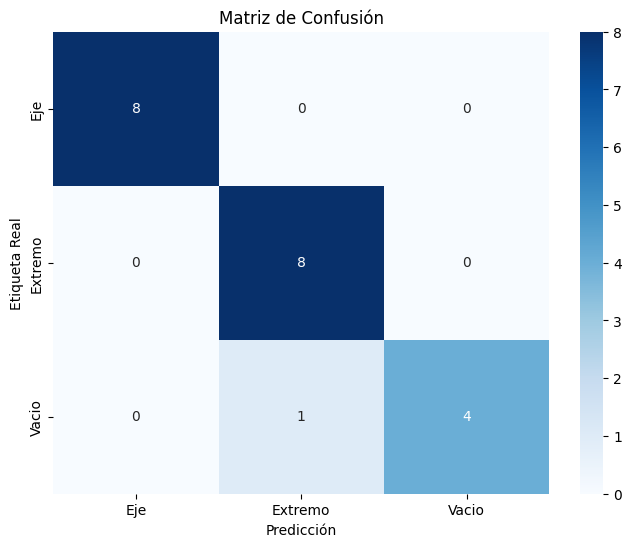

In [28]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from torchmetrics.classification import Accuracy

# Evaluar el modelo y recopilar predicciones reales
model.eval()
y_true = []
y_pred = []
accuracy_metric = Accuracy(task="multiclass", num_classes=num_classes).to(device)

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        predicted = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calcular matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualizar matriz de confusión
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()


### Almacenar métricas

In [29]:
import json
from sklearn.metrics import classification_report

# Calcular reporte de métricas
report = classification_report(y_true, y_pred, target_names=dataset.classes, output_dict=True)

# Guardar en un archivo JSON para trazabilidad
with open("resultados_evaluacion.json", "w") as f:
    json.dump(report, f, indent=4)

print("✅ Resultados guardados en 'resultados_evaluacion.json'")


✅ Resultados guardados en 'resultados_evaluacion.json'


In [33]:
import plotly.graph_objects as go

# Crear gráfico de barras con Plotly
fig = go.Figure()

fig.add_trace(go.Bar(
    x=classes,
    y=precision,
    name="Precisión",
))

fig.add_trace(go.Bar(
    x=classes,
    y=recall,
    name="Recall",
))

fig.add_trace(go.Bar(
    x=classes,
    y=f1_score,
    name="F1-Score",
))

# Mejorar el diseño
fig.update_layout(
    title="Métricas de Clasificación por Clase",
    xaxis_title="Clases",
    yaxis_title="Valor",
    barmode="group",
    template="plotly_white",
    title_font=dict(size=18, color="#333333"),
    xaxis=dict(tickfont=dict(size=12)),
    yaxis=dict(tickfont=dict(size=12), range=[0, 1.1]),
    legend=dict(font=dict(size=12))
)

# Mostrar el gráfico interactivo
fig.show()


## GUARDAR MODELO

In [30]:
torch.save(model.state_dict(), "/content/drive/MyDrive/ATOM2.0/models/classifier_2V.pth")
print("✅ Modelo guardado como 'classifier_2V.pth'")


✅ Modelo guardado como 'classifier_2V.pth'
